In [1]:
from isolation_env import IsolationEnv
from input_agent import InputAgent
from random_agent import RandomAgent
from stratagem import Stratagem
from minimax_alpha_beta_pruning_agent import MinimaxAgentAlphaBetaPruning
from minimax_agent import MinimaxAgent
from expectimax_agent import ExpectimaxAgent
from play import play_vs_other_agent
from heuristics import (
    eval_baseline, eval_pure_mobility, eval_mobility_heavy,
    eval_aggressive, eval_space_control, eval_balanced, eval_pure_space
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


In [2]:
env = IsolationEnv()
input_agent = InputAgent()
env.action_space

Discrete(9)

## Mimimax sin poda y Minimax con poda (AB) contra Stratagem

[1/20]
Player 2 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
  MM puro (J1) vs Stratagem (J2) → 5/8 (62%)
Player 2 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
  Stratagem (J1) vs MM puro (J2) → 5/8 (62%)
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
  AB (J1) vs Stratagem (J2)        → 7/8 (88%)
Player 2 WON
Player 2 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
  Stratagem (J1) vs AB (J2)        → 4/8 (50%)
[2/20]
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 2 WON
  MM puro (J1) vs Stratagem (J2) → 5/8 (62%)
Player 2 WON
Player 1 WON
Player 2 WON
Player 2 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
  Stratagem (J1) vs MM puro (J2) → 4/8 (50%)
Player 1 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 2 W

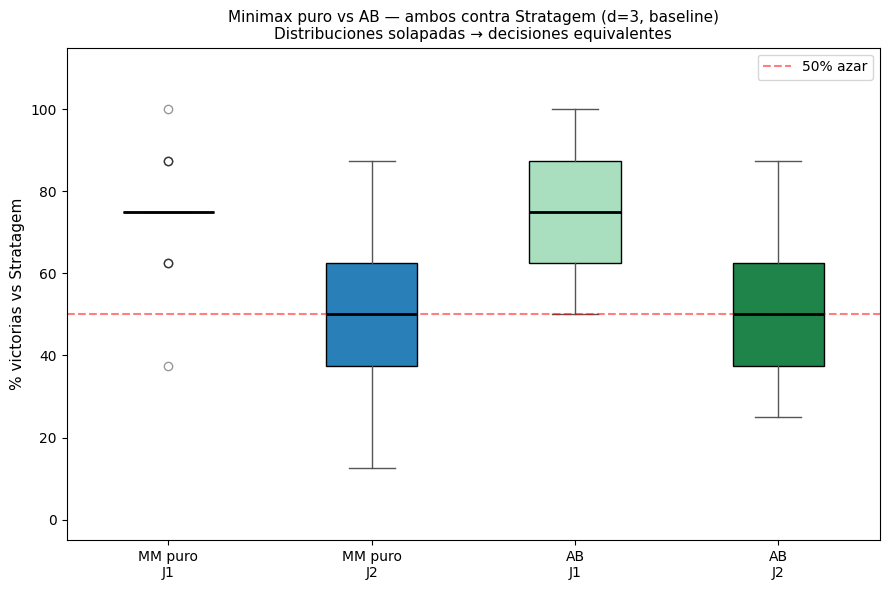

In [ ]:
N_PARTIDAS = 8
N_REPETICIONES = 20

def run_config(agent1_fn, agent2_fn, n_partidas=N_PARTIDAS, verbose=True, label=''):
    wins = 0
    for _ in range(n_partidas):
        env.reset()
        winner = play_vs_other_agent(env, agent1=agent1_fn(), agent2=agent2_fn(), render=False)
        if winner == 1:
            wins += 1
    pct = 100.0 * wins / n_partidas
    if verbose:
        print(f'  {label}→ {wins}/{n_partidas} ({pct:.0f}%)')
    return pct

res_mm_j1, res_mm_j2, res_ab_j1, res_ab_j2 = [], [], [], []

for i in range(N_REPETICIONES):
    print(f"[{i+1}/{N_REPETICIONES}]")

    res_mm_j1.append(run_config(
        agent1_fn=lambda: MinimaxAgent(player=1, depth=3),
        agent2_fn=lambda: Stratagem(2),
        label='MM puro (J1) vs Stratagem (J2) '
    ))
    res_mm_j2.append(100 - run_config(
        agent1_fn=lambda: Stratagem(1),
        agent2_fn=lambda: MinimaxAgent(player=2, depth=3),
        label='Stratagem (J1) vs MM puro (J2) '
    ))
    res_ab_j1.append(run_config(
        agent1_fn=lambda: MinimaxAgentAlphaBetaPruning(player=1, depth=3, eval_fn=eval_baseline),
        agent2_fn=lambda: Stratagem(2),
        label='AB (J1) vs Stratagem (J2)        '
    ))
    res_ab_j2.append(100 - run_config(
        agent1_fn=lambda: Stratagem(1),
        agent2_fn=lambda: MinimaxAgentAlphaBetaPruning(player=2, depth=3, eval_fn=eval_baseline),
        label='Stratagem (J1) vs AB (J2)        '
    ))


print(f"\n{'Agente':<20} {'Posición':<10} {'Mediana':>10} {'Media':>10}")
print('-' * 52)
print(f"{'Minimax puro':<20} {'J1':<10} {np.median(res_mm_j1):>9.1f}% {np.mean(res_mm_j1):>9.1f}%")
print(f"{'Minimax puro':<20} {'J2':<10} {np.median(res_mm_j2):>9.1f}% {np.mean(res_mm_j2):>9.1f}%")
print(f"{'AB':<20} {'J1':<10} {np.median(res_ab_j1):>9.1f}% {np.mean(res_ab_j1):>9.1f}%")
print(f"{'AB':<20} {'J2':<10} {np.median(res_ab_j2):>9.1f}% {np.mean(res_ab_j2):>9.1f}%")


fig, ax = plt.subplots(figsize=(9, 6))

datos  = [res_mm_j1, res_mm_j2, res_ab_j1, res_ab_j2]
labels = ['MM puro\nJ1', 'MM puro\nJ2', 'AB\nJ1', 'AB\nJ2']
colores = ['#AED6F1', '#2980B9', '#A9DFBF', '#1E8449']

bp = ax.boxplot(datos, tick_labels=labels, patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color='#555'),
                capprops=dict(color='#555'),
                flierprops=dict(marker='o', alpha=0.4))

for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)

ax.axhline(50, color='red', linestyle='--', alpha=0.5, label='50% azar')
ax.set_ylabel('% victorias vs Stratagem', fontsize=11)
ax.set_title('Minimax puro vs AB — ambos contra Stratagem (d=3, baseline)\n'
             'Distribuciones solapadas → decisiones equivalentes', fontsize=11)
ax.legend()
ax.set_ylim(-5, 115)
plt.tight_layout()
plt.show()

## Función run_tournament
Corre N torneos de M partidas y devuelve la lista de porcentajes de victoria del J1.
Esos N valores son los puntos del boxplot.

In [ ]:
def run_tournament(agent1_fn, agent2_fn, n_torneos=10, partidas=10, verbose=True):
    resultados = []
    for i in range(n_torneos):
        wins = 0
        for _ in range(partidas):
            env.reset()
            a1 = agent1_fn()
            a2 = agent2_fn()
            winner = play_vs_other_agent(env, agent1=a1, agent2=a2, render=False)
            if winner == 1:
                wins += 1
        pct = 100.0 * wins / partidas
        resultados.append(pct)
        if verbose:
            print(f'  Torneo {i+1}/{n_torneos}: J1 ganó {pct:.1f}%')
    return resultados


In [27]:
HEURISTICAS = {
    'baseline':       eval_baseline,
    'pure_mobility':  eval_pure_mobility,
    'mobility_heavy': eval_mobility_heavy,
    'aggressive':     eval_aggressive,
    'space_control':  eval_space_control,
    'balanced':       eval_balanced,
    'pure_space':     eval_pure_space,
}

PROFUNDIDADES = [2, 3, 4]
N_TORNEOS    = 10
PARTIDAS     = 10


## AB vs Random
- Configuraciones a probar (AB como J1 (vs Random J2) y AB como J2 (vs Random J1))
- Profundidades: 2, 3, 4
- Heurísticas: 7 predefinidas anteriormente

In [ ]:
resultados = {}

for depth in PROFUNDIDADES:
    resultados[depth] = {}
    for nombre, fn in HEURISTICAS.items():
        resultados[depth][nombre] = {}
        
        # --- AB como J1, Random como J2 ---
        print(f"\n[d={depth}] {nombre} — AB(J1) vs Random(J2)")
        res_j1 = run_tournament(
            agent1_fn=lambda fn=fn, d=depth: MinimaxAgentAlphaBetaPruning(player=1, depth=d, eval_fn=fn),
            agent2_fn=lambda: RandomAgent(player=2),
            n_torneos=N_TORNEOS,
            partidas=PARTIDAS
        )
        resultados[depth][nombre]['j1'] = res_j1
        
        # --- Random como J1, AB como J2 ---
        print(f"[d={depth}] {nombre} — Random(J1) vs AB(J2)")
        res_j2 = run_tournament(
            agent1_fn=lambda: RandomAgent(player=1),
            agent2_fn=lambda fn=fn, d=depth: MinimaxAgentAlphaBetaPruning(player=2, depth=d, eval_fn=fn),
            n_torneos=N_TORNEOS,
            partidas=PARTIDAS
        )
        resultados[depth][nombre]['j2'] = [100.0 - x for x in res_j2]

print("\n Experimentos terminados")


[d=2] baseline — AB(J1) vs Random(J2)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
  Torneo 1/10: J1 ganó 100.0%
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
  Torneo 2/10: J1 ganó 100.0%
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
  Torneo 3/10: J1 ganó 100.0%
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
  Torneo 4/10: J1 ganó 100.0%
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
  Torneo 5/10: J1 ganó 100.0%
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
  Torneo 6/10: J1 ganó 100.0%
P

### Boxplots AB vs Random (un gráfico por profundidad)



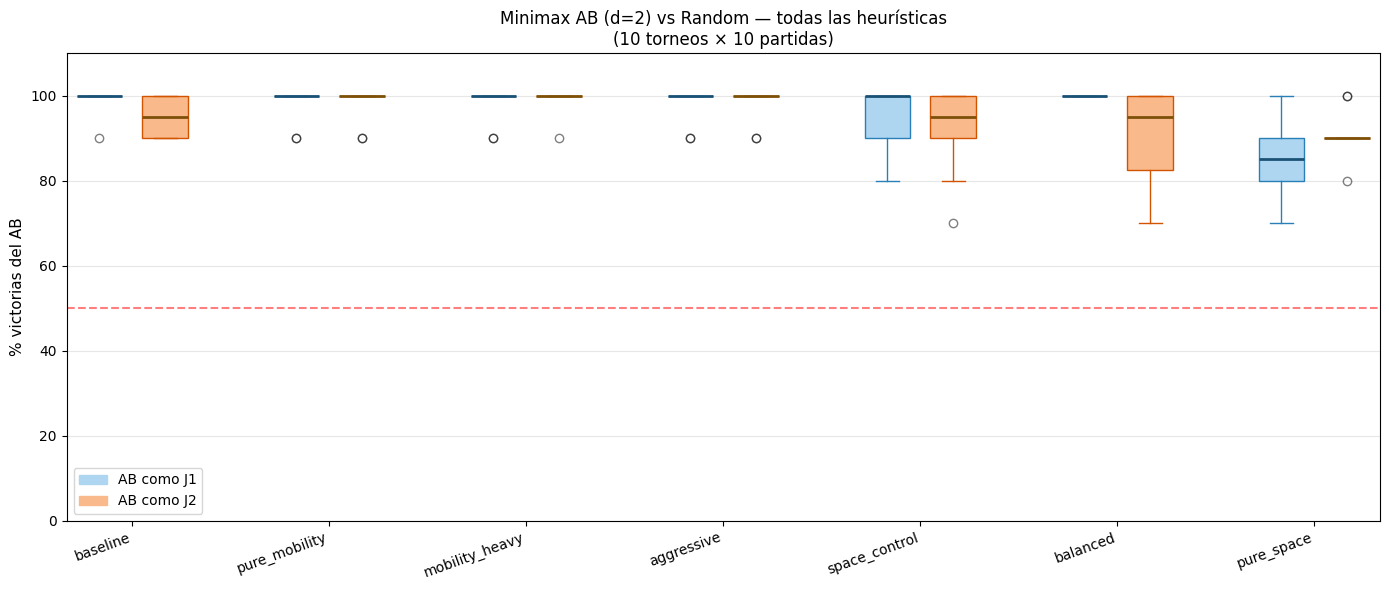

Guardado: boxplot_AB_d2_vs_random.png


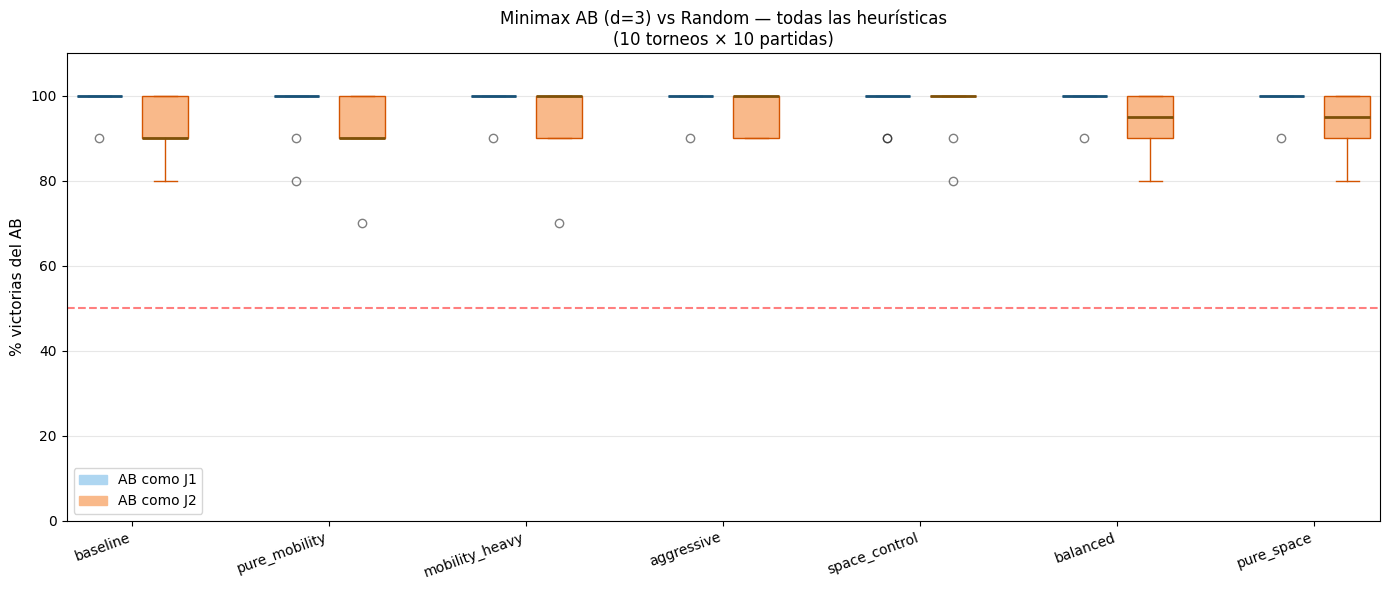

Guardado: boxplot_AB_d3_vs_random.png


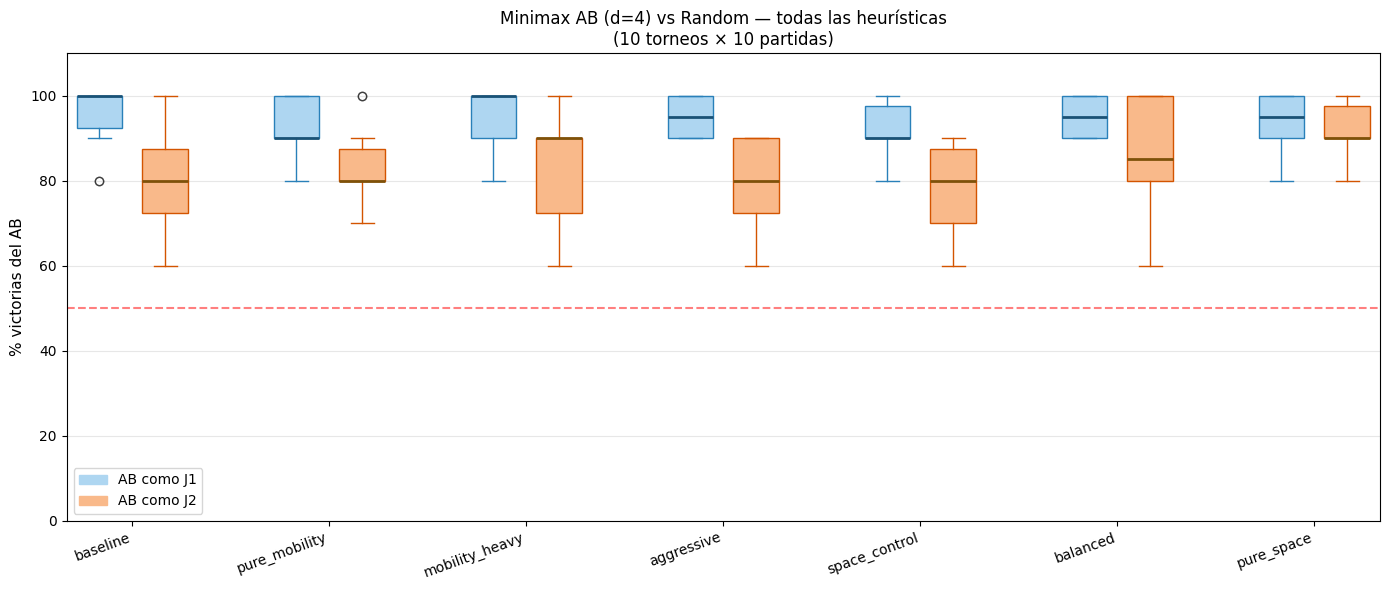

Guardado: boxplot_AB_d4_vs_random.png


In [29]:
def plot_boxplots_por_profundidad(resultados, depth):
    nombres = list(HEURISTICAS.keys())
    n = len(nombres)

    fig, ax = plt.subplots(figsize=(14, 6))

    posiciones_j1 = [i * 3 + 1 for i in range(n)]
    posiciones_j2 = [i * 3 + 2 for i in range(n)]

    datos_j1 = [resultados[depth][nombre]['j1'] for nombre in nombres]
    datos_j2 = [resultados[depth][nombre]['j2'] for nombre in nombres]

    bp1 = ax.boxplot(datos_j1, positions=posiciones_j1, widths=0.7,
                     patch_artist=True,
                     boxprops=dict(facecolor='#AED6F1', color='#2980B9'),
                     medianprops=dict(color='#1A5276', linewidth=2),
                     whiskerprops=dict(color='#2980B9'),
                     capprops=dict(color='#2980B9'),
                     flierprops=dict(marker='o', color='#2980B9', alpha=0.5))

    bp2 = ax.boxplot(datos_j2, positions=posiciones_j2, widths=0.7,
                     patch_artist=True,
                     boxprops=dict(facecolor='#F9B98A', color='#D35400'),
                     medianprops=dict(color='#7E5109', linewidth=2),
                     whiskerprops=dict(color='#D35400'),
                     capprops=dict(color='#D35400'),
                     flierprops=dict(marker='o', color='#D35400', alpha=0.5))

    ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% (azar)')

    centros = [i * 3 + 1.5 for i in range(n)]
    ax.set_xticks(centros)
    ax.set_xticklabels(nombres, rotation=20, ha='right', fontsize=10)
    ax.set_ylim(0, 110)
    ax.set_ylabel('% victorias del AB', fontsize=11)
    ax.set_title(
        f'Minimax AB (d={depth}) vs Random — todas las heurísticas\n'
        f'({N_TORNEOS} torneos × {PARTIDAS} partidas)',
        fontsize=12)

    patch_j1 = mpatches.Patch(color='#AED6F1', label='AB como J1')
    patch_j2 = mpatches.Patch(color='#F9B98A', label='AB como J2')
    ax.legend(handles=[patch_j1, patch_j2], fontsize=10)

    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'boxplot_AB_d{depth}_vs_random.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardado: boxplot_AB_d{depth}_vs_random.png')


for depth in PROFUNDIDADES:
    plot_boxplots_por_profundidad(resultados, depth)


In [30]:
print(f"{'Config':<25} {'d':>3} {'Mediana J1':>12} {'Mediana J2':>12} {'Promedio':>10}")
print('-' * 65)

mejor_config = None
mejor_prom   = -1

for depth in PROFUNDIDADES:
    for nombre in HEURISTICAS:
        med_j1 = np.median(resultados[depth][nombre]['j1'])
        med_j2 = np.median(resultados[depth][nombre]['j2'])
        prom   = (med_j1 + med_j2) / 2
        print(f'{nombre:<25} {depth:>3} {med_j1:>11.1f}% {med_j2:>11.1f}% {prom:>9.1f}%')
        if prom > mejor_prom:
            mejor_prom   = prom
            mejor_config = (depth, nombre)

print('-' * 65)
print(f'\n✓ Mejor configuración vs Random: d={mejor_config[0]}, heurística={mejor_config[1]}')
print(f'   Promedio de medianas (J1+J2)/2 = {mejor_prom:.1f}%')


Config                      d   Mediana J1   Mediana J2   Promedio
-----------------------------------------------------------------
baseline                    2       100.0%        95.0%      97.5%
pure_mobility               2       100.0%       100.0%     100.0%
mobility_heavy              2       100.0%       100.0%     100.0%
aggressive                  2       100.0%       100.0%     100.0%
space_control               2       100.0%        95.0%      97.5%
balanced                    2       100.0%        95.0%      97.5%
pure_space                  2        85.0%        90.0%      87.5%
baseline                    3       100.0%        90.0%      95.0%
pure_mobility               3       100.0%        90.0%      95.0%
mobility_heavy              3       100.0%       100.0%     100.0%
aggressive                  3       100.0%       100.0%     100.0%
space_control               3       100.0%       100.0%     100.0%
balanced                    3       100.0%        95.0%      97

## AB vs Stratagem
Misma estructura que vs Random pero contra Stratagem.
Se prueba cada configuración de AB en ambas posiciones.


In [ ]:
resultados_strat = {}

for depth in PROFUNDIDADES:
    resultados_strat[depth] = {}
    for nombre, fn in HEURISTICAS.items():
        resultados_strat[depth][nombre] = {}

        # --- AB como J1, Stratagem como J2 ---
        print(f'\n[d={depth}] {nombre} — AB(J1) vs Stratagem(J2)')
        res_j1 = run_tournament(
            agent1_fn=lambda fn=fn, d=depth: MinimaxAgentAlphaBetaPruning(player=1, depth=d, eval_fn=fn),
            agent2_fn=lambda: Stratagem(2),
            n_torneos=N_TORNEOS,
            partidas=PARTIDAS
        )
        resultados_strat[depth][nombre]['j1'] = res_j1

        # --- Stratagem como J1, AB como J2 ---
        print(f'[d={depth}] {nombre} — Stratagem(J1) vs AB(J2)')
        res_j2 = run_tournament(
            agent1_fn=lambda: Stratagem(1),
            agent2_fn=lambda fn=fn, d=depth: MinimaxAgentAlphaBetaPruning(player=2, depth=d, eval_fn=fn),
            n_torneos=N_TORNEOS,
            partidas=PARTIDAS
        )
        resultados_strat[depth][nombre]['j2'] = [100.0 - x for x in res_j2]

print('\n AB vs Stratagem terminado')



[d=2] baseline — AB(J1) vs Stratagem(J2)
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 1 WON
  Torneo 1/10: J1 ganó 60.0%
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 2 WON
Player 1 WON
  Torneo 2/10: J1 ganó 70.0%
Player 1 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
  Torneo 3/10: J1 ganó 60.0%
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
  Torneo 4/10: J1 ganó 80.0%
Player 1 WON
Player 2 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
  Torneo 5/10: J1 ganó 60.0%
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 2 WON
  Torneo 6/10: J1 ganó 70.0%
Play

### Boxplots AB vs Stratagem

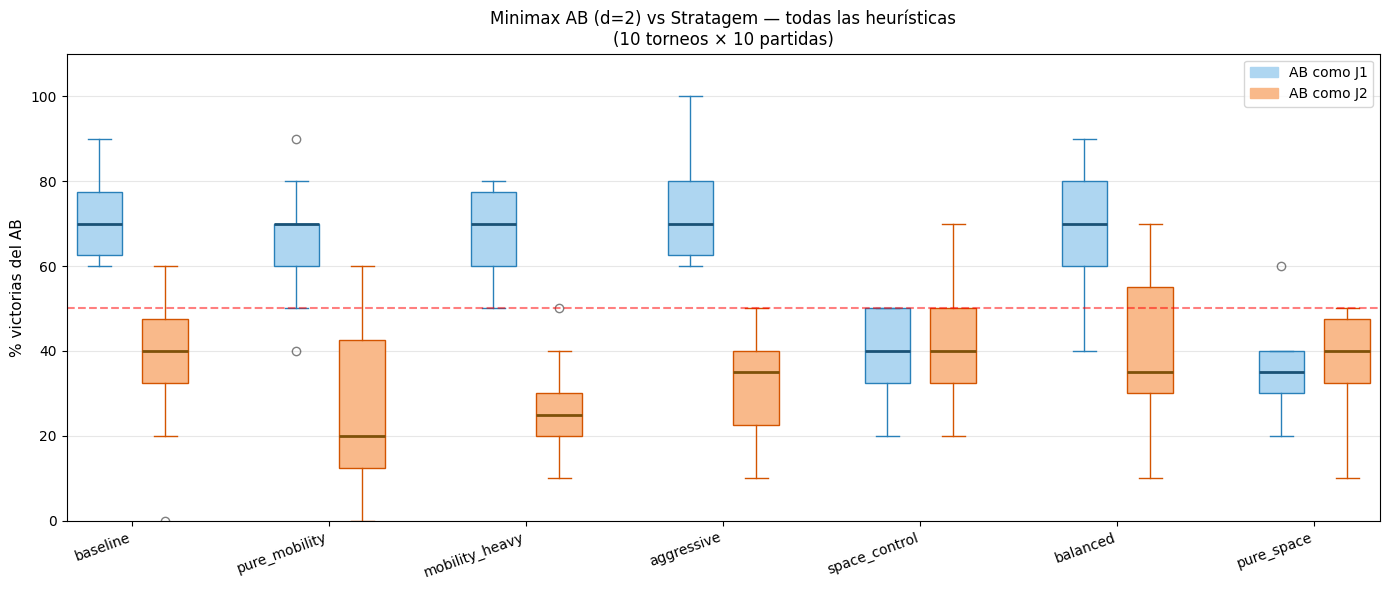

Guardado: boxplot_AB_d2_vs_stratagem.png


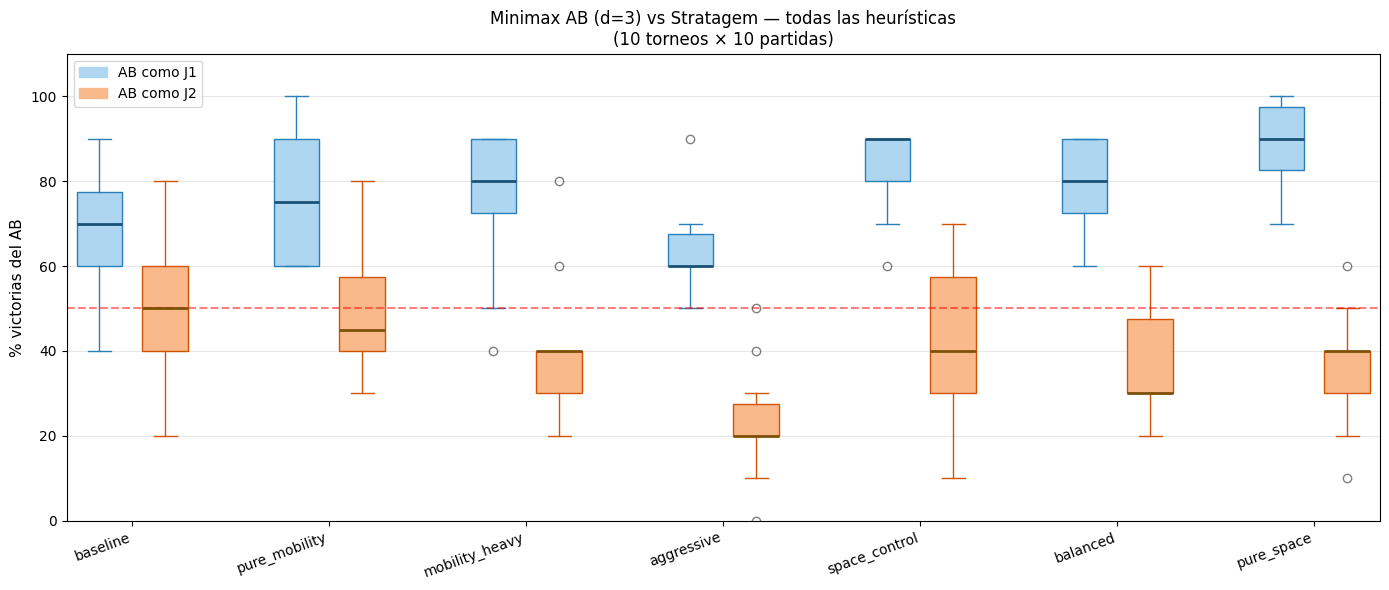

Guardado: boxplot_AB_d3_vs_stratagem.png


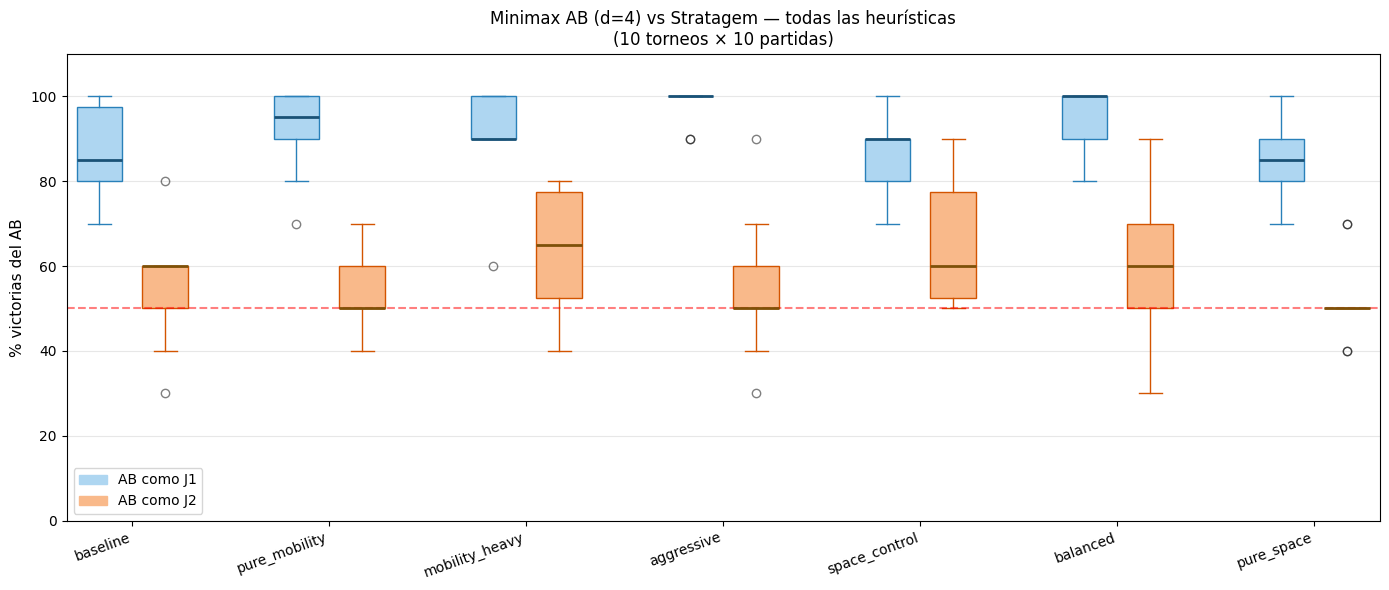

Guardado: boxplot_AB_d4_vs_stratagem.png


In [33]:
def plot_boxplots_strat(resultados_strat, depth):
    nombres = list(HEURISTICAS.keys())
    n = len(nombres)

    fig, ax = plt.subplots(figsize=(14, 6))

    posiciones_j1 = [i * 3 + 1 for i in range(n)]
    posiciones_j2 = [i * 3 + 2 for i in range(n)]

    datos_j1 = [resultados_strat[depth][nombre]['j1'] for nombre in nombres]
    datos_j2 = [resultados_strat[depth][nombre]['j2'] for nombre in nombres]

    bp1 = ax.boxplot(datos_j1, positions=posiciones_j1, widths=0.7,
                     patch_artist=True,
                     boxprops=dict(facecolor='#AED6F1', color='#2980B9'),
                     medianprops=dict(color='#1A5276', linewidth=2),
                     whiskerprops=dict(color='#2980B9'),
                     capprops=dict(color='#2980B9'),
                     flierprops=dict(marker='o', color='#2980B9', alpha=0.5))

    bp2 = ax.boxplot(datos_j2, positions=posiciones_j2, widths=0.7,
                     patch_artist=True,
                     boxprops=dict(facecolor='#F9B98A', color='#D35400'),
                     medianprops=dict(color='#7E5109', linewidth=2),
                     whiskerprops=dict(color='#D35400'),
                     capprops=dict(color='#D35400'),
                     flierprops=dict(marker='o', color='#D35400', alpha=0.5))

    ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% (azar)')

    centros = [i * 3 + 1.5 for i in range(n)]
    ax.set_xticks(centros)
    ax.set_xticklabels(nombres, rotation=20, ha='right', fontsize=10)
    ax.set_ylim(0, 110)
    ax.set_ylabel('% victorias del AB', fontsize=11)
    ax.set_title(
        f'Minimax AB (d={depth}) vs Stratagem — todas las heurísticas\n'
        f'({N_TORNEOS} torneos × {PARTIDAS} partidas)',
        fontsize=12)

    patch_j1 = mpatches.Patch(color='#AED6F1', label='AB como J1')
    patch_j2 = mpatches.Patch(color='#F9B98A', label='AB como J2')
    ax.legend(handles=[patch_j1, patch_j2], fontsize=10)

    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'boxplot_AB_d{depth}_vs_stratagem.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardado: boxplot_AB_d{depth}_vs_stratagem.png')


for depth in PROFUNDIDADES:
    plot_boxplots_strat(resultados_strat, depth)


In [34]:
print(f"{'Config':<25} {'d':>3} {'Mediana J1':>12} {'Mediana J2':>12} {'Promedio':>10}")
print('-' * 65)

mejor_strat = None
mejor_prom_strat = -1

for depth in PROFUNDIDADES:
    for nombre in HEURISTICAS:
        med_j1 = np.median(resultados_strat[depth][nombre]['j1'])
        med_j2 = np.median(resultados_strat[depth][nombre]['j2'])
        prom   = (med_j1 + med_j2) / 2
        print(f'{nombre:<25} {depth:>3} {med_j1:>11.1f}% {med_j2:>11.1f}% {prom:>9.1f}%')
        if prom > mejor_prom_strat:
            mejor_prom_strat = prom
            mejor_strat = (depth, nombre)

print('-' * 65)
print(f'\n✓ Mejor config vs Stratagem: d={mejor_strat[0]}, heurística={mejor_strat[1]}')
print(f'   Promedio de medianas (J1+J2)/2 = {mejor_prom_strat:.1f}%')


Config                      d   Mediana J1   Mediana J2   Promedio
-----------------------------------------------------------------
baseline                    2        70.0%        40.0%      55.0%
pure_mobility               2        70.0%        20.0%      45.0%
mobility_heavy              2        70.0%        25.0%      47.5%
aggressive                  2        70.0%        35.0%      52.5%
space_control               2        40.0%        40.0%      40.0%
balanced                    2        70.0%        35.0%      52.5%
pure_space                  2        35.0%        40.0%      37.5%
baseline                    3        70.0%        50.0%      60.0%
pure_mobility               3        75.0%        45.0%      60.0%
mobility_heavy              3        80.0%        40.0%      60.0%
aggressive                  3        60.0%        20.0%      40.0%
space_control               3        90.0%        40.0%      65.0%
balanced                    3        80.0%        30.0%      55

In [37]:
N_PARTIDAS = 8

def run_config(agent1_fn, agent2_fn, n_partidas=N_PARTIDAS, verbose=True, label=''):
    wins = 0
    for _ in range(n_partidas):
        env.reset()
        winner = play_vs_other_agent(env, agent1=agent1_fn(), agent2=agent2_fn(), render=False)
        if winner == 1:
            wins += 1
    pct = 100.0 * wins / n_partidas
    if verbose:
        print(f'  {label}→ {wins}/{n_partidas} ({pct:.0f}%)')
    return pct

## Expectimax vs Random

In [39]:
print("=== Expectimax vs Random ===")
resultados_exp_random = {}

for depth in [2, 3]:
    resultados_exp_random[depth] = {}
    for nombre, fn in HEURISTICAS.items():
        print(f"\n[d={depth}] {nombre}")
        wr_j1 = run_config(
            agent1_fn=lambda fn=fn, d=depth: ExpectimaxAgent(player=1, depth=d, eval_fn=fn),
            agent2_fn=lambda: RandomAgent(player=2),
            label='Exp(J1) vs Rand(J2) '
        )
        wr_j2_raw = run_config(
            agent1_fn=lambda: RandomAgent(player=1),
            agent2_fn=lambda fn=fn, d=depth: ExpectimaxAgent(player=2, depth=d, eval_fn=fn),
            label='Rand(J1) vs Exp(J2) '
        )
        resultados_exp_random[depth][nombre] = {
            'j1': wr_j1,
            'j2': 100.0 - wr_j2_raw
        }

print("\n Expectimax vs Random terminado")

=== Expectimax vs Random ===

[d=2] baseline
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
  Exp(J1) vs Rand(J2) → 8/8 (100%)
Player 2 WON
Player 1 WON
Player 2 WON
Player 2 WON
Player 2 WON
Player 2 WON
Player 2 WON
Player 2 WON
  Rand(J1) vs Exp(J2) → 1/8 (12%)

[d=2] pure_mobility
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
  Exp(J1) vs Rand(J2) → 8/8 (100%)
Player 2 WON
Player 2 WON
Player 2 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 2 WON
Player 2 WON
  Rand(J1) vs Exp(J2) → 1/8 (12%)

[d=2] mobility_heavy
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
  Exp(J1) vs Rand(J2) → 7/8 (88%)
Player 2 WON
Player 2 WON
Player 2 WON
Player 2 WON
Player 2 WON
Player 2 WON
Player 1 WON
Player 2 WON
  Rand(J1) vs Exp(J2) → 1/8 (12%)

[d=2] aggressive
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON

### Boxplots Expectimax vs Random

C:\Users\flore\AppData\Local\Temp\ipykernel_4256\2810613927.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos, labels=[f'd={d}' for d in depths],


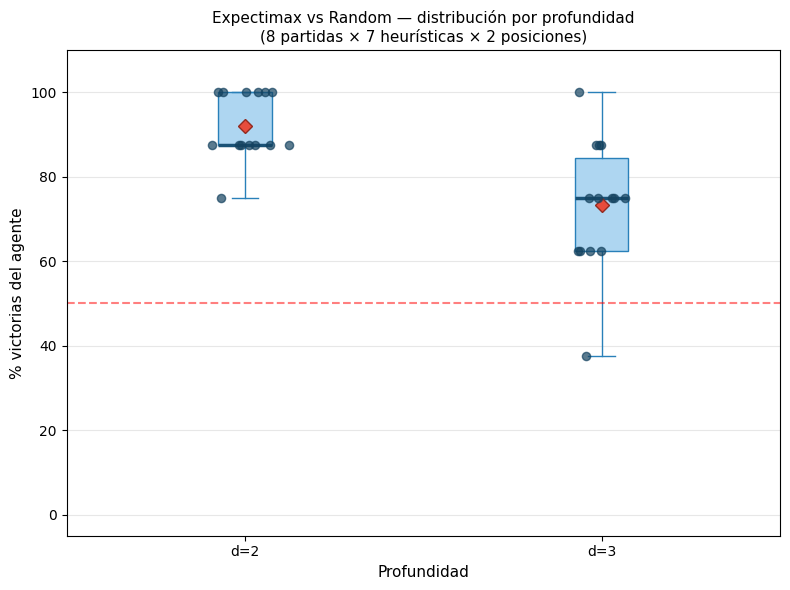


 Prof │   Min │    Q1 │   Med │  Media │    Q3 │   Max
──────┼───────┼───────┼───────┼────────┼───────┼───────
  d=2 │   75% │   88% │   88% │  92.0% │  100% │  100%
  d=3 │   38% │   62% │   75% │  73.2% │   84% │  100%

Config                      d   Exp=J1   Exp=J2   Promedio
----------------------------------------------------------
baseline                    2     100%      88%      93.8%
pure_mobility               2     100%      88%      93.8%
mobility_heavy              2      88%      88%      87.5%
aggressive                  2     100%     100%     100.0%
space_control               2     100%     100%     100.0%
balanced                    2      75%      88%      81.2%
pure_space                  2      88%      88%      87.5%
baseline                    3      75%      62%      68.8%
pure_mobility               3      62%      88%      75.0%
mobility_heavy              3      62%      75%      68.8%
aggressive                  3      38%      88%      62.5%
space_cont

In [40]:
def plot_boxplot_por_depth(resultados_dict, titulo, filename, depths=[2, 3]):
    nombres_heur = list(HEURISTICAS.keys())
    datos = []
    for depth in depths:
        rates = []
        for nombre in nombres_heur:
            rates.append(resultados_dict[depth][nombre]['j1'])
            rates.append(resultados_dict[depth][nombre]['j2'])
        datos.append(rates)

    fig, ax = plt.subplots(figsize=(8, 6))
    bp = ax.boxplot(datos, labels=[f'd={d}' for d in depths],
                    patch_artist=True, showmeans=True,
                    boxprops=dict(facecolor='#AED6F1', color='#2980B9'),
                    medianprops=dict(color='#1A5276', linewidth=2.5),
                    meanprops=dict(marker='D', markerfacecolor='#E74C3C',
                                   markeredgecolor='#922B21', markersize=7),
                    whiskerprops=dict(color='#2980B9'),
                    capprops=dict(color='#2980B9'),
                    flierprops=dict(marker='o', color='#2980B9', alpha=0.5))

    for i, rates in enumerate(datos):
        jitter = np.random.normal(i + 1, 0.06, size=len(rates))
        ax.scatter(jitter, rates, color='#154360', s=35, alpha=0.7, zorder=5)

    ax.axhline(50, color='red', linestyle='--', alpha=0.5)
    ax.set_ylim(-5, 110)
    ax.set_ylabel('% victorias del agente', fontsize=11)
    ax.set_xlabel('Profundidad', fontsize=11)
    ax.set_title(f'{titulo}\n({N_PARTIDAS} partidas × 7 heurísticas × 2 posiciones)', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n{'Prof':>5} │ {'Min':>5} │ {'Q1':>5} │ {'Med':>5} │ {'Media':>6} │ {'Q3':>5} │ {'Max':>5}")
    print('──────┼───────┼───────┼───────┼────────┼───────┼───────')
    for depth, rates in zip(depths, datos):
        arr = np.array(rates)
        print(f"  d={depth} │ {arr.min():>4.0f}% │ {np.percentile(arr,25):>4.0f}% │"
              f" {np.median(arr):>4.0f}% │ {arr.mean():>5.1f}% │"
              f" {np.percentile(arr,75):>4.0f}% │ {arr.max():>4.0f}%")

plot_boxplot_por_depth(resultados_exp_random,
                       'Expectimax vs Random — distribución por profundidad',
                       'boxplot_expectimax_vs_random.png')

print(f"\n{'Config':<25} {'d':>3} {'Exp=J1':>8} {'Exp=J2':>8} {'Promedio':>10}")
print('-' * 58)
mejor_exp_random, mejor_prom = None, -1
for depth in [2, 3]:
    for nombre in HEURISTICAS:
        wr_j1 = resultados_exp_random[depth][nombre]['j1']
        wr_j2 = resultados_exp_random[depth][nombre]['j2']
        prom  = (wr_j1 + wr_j2) / 2
        print(f'{nombre:<25} {depth:>3} {wr_j1:>7.0f}% {wr_j2:>7.0f}% {prom:>9.1f}%')
        if prom > mejor_prom:
            mejor_prom, mejor_exp_random = prom, (depth, nombre)
print('-' * 58)
print(f'\n✓ Mejor: d={mejor_exp_random[0]}, heurística={mejor_exp_random[1]} ({mejor_prom:.1f}%)')

## Expectimax vs Stratagem

In [41]:
print("=== Expectimax vs Stratagem ===")
resultados_exp_strat = {}

for depth in [2, 3]:
    resultados_exp_strat[depth] = {}
    for nombre, fn in HEURISTICAS.items():
        print(f"\n[d={depth}] {nombre}")
        wr_j1 = run_config(
            agent1_fn=lambda fn=fn, d=depth: ExpectimaxAgent(player=1, depth=d, eval_fn=fn),
            agent2_fn=lambda: Stratagem(2),
            label='Exp(J1) vs Strat(J2) '
        )
        wr_j2_raw = run_config(
            agent1_fn=lambda: Stratagem(1),
            agent2_fn=lambda fn=fn, d=depth: ExpectimaxAgent(player=2, depth=d, eval_fn=fn),
            label='Strat(J1) vs Exp(J2) '
        )
        resultados_exp_strat[depth][nombre] = {
            'j1': wr_j1,
            'j2': 100.0 - wr_j2_raw
        }

print("\n Expectimax vs Stratagem terminado")

=== Expectimax vs Stratagem ===

[d=2] baseline
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
  Exp(J1) vs Strat(J2) → 8/8 (100%)
Player 2 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 2 WON
  Strat(J1) vs Exp(J2) → 3/8 (38%)

[d=2] pure_mobility
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
  Exp(J1) vs Strat(J2) → 8/8 (100%)
Player 2 WON
Player 1 WON
Player 2 WON
Player 2 WON
Player 2 WON
Player 2 WON
Player 1 WON
Player 2 WON
  Strat(J1) vs Exp(J2) → 2/8 (25%)

[d=2] mobility_heavy
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
  Exp(J1) vs Strat(J2) → 8/8 (100%)
Player 2 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 2 WON
Player 2 WON
  Strat(J1) vs Exp(J2) → 3/8 (38%)

[d=2] aggressive
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Pl

### Boxplots Expectimax vs Stratagem

C:\Users\flore\AppData\Local\Temp\ipykernel_4256\2810613927.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos, labels=[f'd={d}' for d in depths],


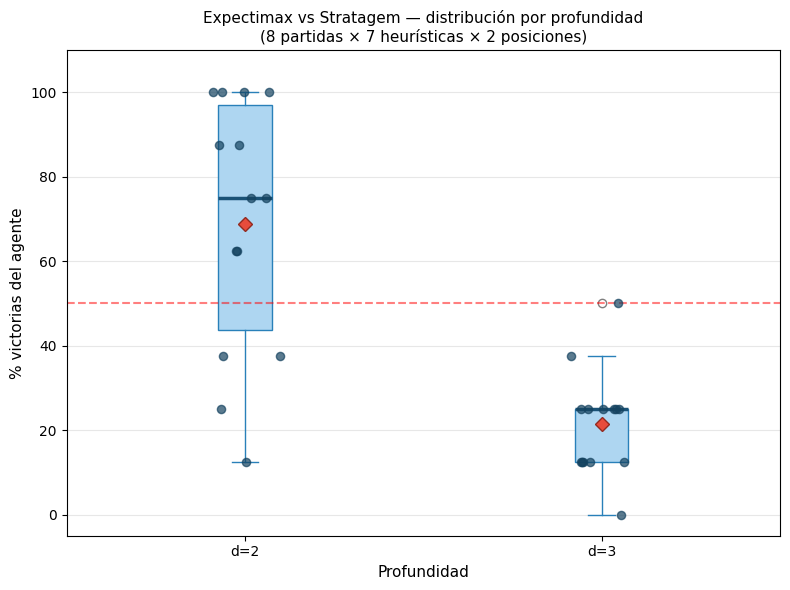


 Prof │   Min │    Q1 │   Med │  Media │    Q3 │   Max
──────┼───────┼───────┼───────┼────────┼───────┼───────
  d=2 │   12% │   44% │   75% │  68.8% │   97% │  100%
  d=3 │    0% │   12% │   25% │  21.4% │   25% │   50%

Config                      d   Exp=J1   Exp=J2   Promedio
----------------------------------------------------------
baseline                    2     100%      62%      81.2%
pure_mobility               2     100%      75%      87.5%
mobility_heavy              2     100%      62%      81.2%
aggressive                  2     100%      12%      56.2%
space_control               2      75%      25%      50.0%
balanced                    2      88%      38%      62.5%
pure_space                  2      88%      38%      62.5%
baseline                    3      12%      25%      18.8%
pure_mobility               3      25%      12%      18.8%
mobility_heavy              3      12%       0%       6.2%
aggressive                  3      25%      50%      37.5%
space_cont

In [42]:
plot_boxplot_por_depth(resultados_exp_strat,
                       'Expectimax vs Stratagem — distribución por profundidad',
                       'boxplot_expectimax_vs_stratagem.png')

print(f"\n{'Config':<25} {'d':>3} {'Exp=J1':>8} {'Exp=J2':>8} {'Promedio':>10}")
print('-' * 58)
mejor_exp_strat, mejor_prom = None, -1
for depth in [2, 3]:
    for nombre in HEURISTICAS:
        wr_j1 = resultados_exp_strat[depth][nombre]['j1']
        wr_j2 = resultados_exp_strat[depth][nombre]['j2']
        prom  = (wr_j1 + wr_j2) / 2
        print(f'{nombre:<25} {depth:>3} {wr_j1:>7.0f}% {wr_j2:>7.0f}% {prom:>9.1f}%')
        if prom > mejor_prom:
            mejor_prom, mejor_exp_strat = prom, (depth, nombre)
print('-' * 58)
print(f'\n✓ Mejor: d={mejor_exp_strat[0]}, heurística={mejor_exp_strat[1]} ({mejor_prom:.1f}%)')


## Random vs Stratagem


=== Random vs Stratagem ===
Player 2 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 2 WON
Player 2 WON
Player 2 WON
Player 1 WON
  Rand(J1) vs Strat(J2) → 2/8 (25%)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
  Strat(J1) vs Rand(J2) → 7/8 (88%)

Random J1: 25%  |  Random J2: 12%  |  Promedio: 18.8%


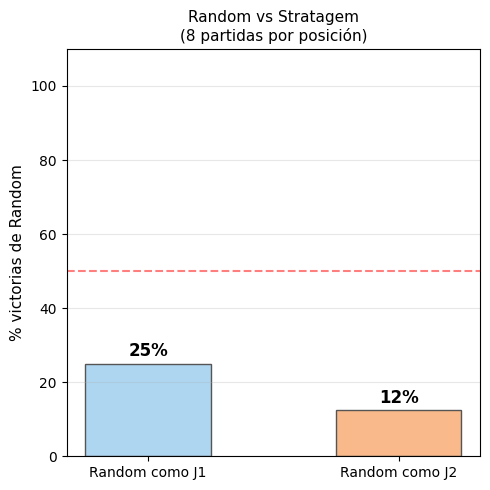

In [43]:
print("=== Random vs Stratagem ===")
wr_rand_j1 = run_config(
    agent1_fn=lambda: RandomAgent(player=1),
    agent2_fn=lambda: Stratagem(2),
    label='Rand(J1) vs Strat(J2) '
)
wr_rand_j2 = 100.0 - run_config(
    agent1_fn=lambda: Stratagem(1),
    agent2_fn=lambda: RandomAgent(player=2),
    label='Strat(J1) vs Rand(J2) '
)
resultados_random_strat = {'j1': wr_rand_j1, 'j2': wr_rand_j2}
print(f'\nRandom J1: {wr_rand_j1:.0f}%  |  Random J2: {wr_rand_j2:.0f}%  |  Promedio: {(wr_rand_j1+wr_rand_j2)/2:.1f}%')

fig, ax = plt.subplots(figsize=(5, 5))
valores = [resultados_random_strat['j1'], resultados_random_strat['j2']]
barras = ax.bar(['Random como J1', 'Random como J2'], valores,
                color=['#AED6F1', '#F9B98A'], edgecolor='#555', width=0.5)
for barra, val in zip(barras, valores):
    ax.text(barra.get_x() + barra.get_width()/2, val + 2,
            f'{val:.0f}%', ha='center', fontsize=12, fontweight='bold')
ax.axhline(50, color='red', linestyle='--', alpha=0.5)
ax.set_ylim(0, 110)
ax.set_ylabel('% victorias de Random', fontsize=11)
ax.set_title(f'Random vs Stratagem\n({N_PARTIDAS} partidas por posición)', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('barplot_random_vs_stratagem.png', dpi=150, bbox_inches='tight')
plt.show()

## AB vs Expectimax

In [ ]:


PROFUNDIDADES_AB  = [2, 3, 4]
PROFUNDIDADES_EXP = [2, 3]

resultados_ab_vs_exp = {'ab': [], 'exp': []}

configs_ab  = [(d, n, fn) for d in PROFUNDIDADES_AB  for n, fn in HEURISTICAS.items()]
configs_exp = [(d, n, fn) for d in PROFUNDIDADES_EXP for n, fn in HEURISTICAS.items()]

total = len(configs_ab) * len(configs_exp) * 2
contador = 0

for d_ab, n_ab, fn_ab in configs_ab:
    for d_exp, n_exp, fn_exp in configs_exp:

        # AB(J1) vs Expectimax(J2)
        contador += 1
        print(f"[{contador}/{total}] AB(d={d_ab},{n_ab}) vs Exp(d={d_exp},{n_exp})")
        wr = run_config(
            agent1_fn=lambda fn=fn_ab, d=d_ab: MinimaxAgentAlphaBetaPruning(player=1, depth=d, eval_fn=fn),
            agent2_fn=lambda fn=fn_exp, d=d_exp: ExpectimaxAgent(player=2, depth=d, eval_fn=fn),
            verbose=False
        )
        resultados_ab_vs_exp['ab'].append(wr)
        resultados_ab_vs_exp['exp'].append(100.0 - wr)

        # Expectimax(J1) vs AB(J2)
        contador += 1
        print(f"[{contador}/{total}] Exp(d={d_exp},{n_exp}) vs AB(d={d_ab},{n_ab})")
        wr = run_config(
            agent1_fn=lambda fn=fn_exp, d=d_exp: ExpectimaxAgent(player=1, depth=d, eval_fn=fn),
            agent2_fn=lambda fn=fn_ab, d=d_ab: MinimaxAgentAlphaBetaPruning(player=2, depth=d, eval_fn=fn),
            verbose=False
        )
        resultados_ab_vs_exp['exp'].append(wr)
        resultados_ab_vs_exp['ab'].append(100.0 - wr)

print("\n Terminado")

[1/588] AB(d=2,baseline) vs Exp(d=2,baseline)
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
[2/588] Exp(d=2,baseline) vs AB(d=2,baseline)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
[3/588] AB(d=2,baseline) vs Exp(d=2,pure_mobility)
Player 1 WON
Player 2 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
[4/588] Exp(d=2,pure_mobility) vs AB(d=2,baseline)
Player 2 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
[5/588] AB(d=2,baseline) vs Exp(d=2,mobility_heavy)
Player 2 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
[6/588] Exp(d=2,mobility_heavy) vs AB(d=2,baseline)
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
[7/588] AB(d=2,baseline) vs Exp(d=2,aggressive)
Player 1 WON
Player 2 WON
Play

### Boxplots AB vs Expectimax

C:\Users\flore\AppData\Local\Temp\ipykernel_4256\589383066.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos, labels=labels, patch_artist=True, showmeans=True,


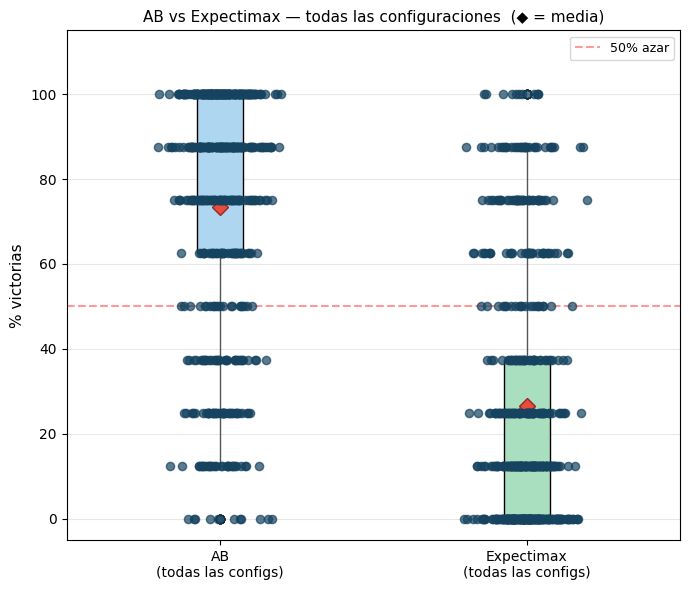


Agente                    │   Min │ Mediana │  Media │   Max
───────────────────────────────────────────────────────
AB (todas las configs)    │    0% │     88% │  73.5% │  100%
Expectimax (todas las configs) │    0% │     12% │  26.5% │  100%


In [ ]:

datos  = [resultados_ab_vs_exp['ab'], resultados_ab_vs_exp['exp']]
labels = ['AB\n(todas las configs)', 'Expectimax\n(todas las configs)']

fig, ax = plt.subplots(figsize=(7, 6))
bp = ax.boxplot(datos, labels=labels, patch_artist=True, showmeans=True,
                medianprops=dict(color='#1A5276', linewidth=2.5),
                meanprops=dict(marker='D', markerfacecolor='#E74C3C',
                               markeredgecolor='#922B21', markersize=8),
                whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
                flierprops=dict(marker='o', color='#555', alpha=0.4))

bp['boxes'][0].set_facecolor('#AED6F1')
bp['boxes'][1].set_facecolor('#A9DFBF')

for i, rates in enumerate(datos):
    jitter = np.random.normal(i + 1, 0.07, size=len(rates))
    ax.scatter(jitter, rates, color='#154360', s=35, alpha=0.7, zorder=5)

ax.axhline(50, color='red', linestyle='--', alpha=0.4, label='50% azar')
ax.set_ylim(-5, 115)
ax.set_ylabel('% victorias', fontsize=11)
ax.set_title('AB vs Expectimax — todas las configuraciones  (◆ = media)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


print(f"\n{'Agente':<25} │ {'Min':>5} │ {'Mediana':>7} │ {'Media':>6} │ {'Max':>5}")
print('─' * 55)
for label, rates in zip(labels, datos):
    arr = np.array(rates)
    print(f"{label.replace(chr(10),' '):<25} │ {arr.min():>4.0f}% │"
          f" {np.median(arr):>6.0f}% │ {arr.mean():>5.1f}% │ {arr.max():>4.0f}%")

In [ ]:
import json, re
from collections import defaultdict

NOTEBOOK_PATH = "isolation.ipynb"

with open(NOTEBOOK_PATH, encoding="utf-8") as f:
    nb = json.load(f)

raw_text = None
for cell in nb["cells"]:
    text = "".join("".join(o.get("text", [])) for o in cell.get("outputs", []))
    if re.search(r"\[\d+/588\] (AB|Exp)\(d=", text):
        raw_text = text
        break

if raw_text is None:
    raise RuntimeError("No encontré el output de AB vs Expectimax. "
                        "¿Guardaste el notebook (Ctrl+S) después de correr esa celda?")

parts = re.split(r"(\[\d+/588\] [^\n]*)\n", raw_text)
headers, contents = parts[1::2], parts[2::2]
pat = re.compile(r"\[(\d+)/588\] (AB|Exp)\(d=(\d+),(\w+)\) vs (AB|Exp)\(d=(\d+),(\w+)\)")

results_as_j1 = defaultdict(list)
results_as_j2 = defaultdict(list)

for h, c in zip(headers, contents):
    m = pat.match(h)
    if not m:
        continue
    _, t1, d1, n1, t2, d2, n2 = m.groups()
    wins = c.count("Player 1 WON")
    total = wins + c.count("Player 2 WON")
    wr = 100.0 * wins / total
    results_as_j1[(t1, int(d1), n1)].append(wr)
    results_as_j2[(t2, int(d2), n2)].append(100.0 - wr)

heurs = ['baseline','pure_mobility','mobility_heavy','aggressive',
         'space_control','balanced','pure_space']

print(f"{'Config':<25} {'d':>3} {'MedJ1':>8} {'MedJ2':>8} {'Promedio':>10}")
print('-'*60)

mejor, mejor_prom = None, -1
for d in [2, 3, 4]:
    for h in heurs:
        key = ('AB', d, h)
        j1, j2 = results_as_j1.get(key), results_as_j2.get(key)
        if not j1 or not j2:
            continue
        med_j1, med_j2 = np.median(j1), np.median(j2)
        prom = (med_j1 + med_j2) / 2
        print(f'{h:<25} {d:>3} {med_j1:>7.2f}% {med_j2:>7.2f}% {prom:>9.2f}%')
        if prom > mejor_prom:
            mejor_prom, mejor = prom, (d, h)

print('-'*60)
print(f"\n✓ Mejor configuración AB vs Expectimax: d={mejor[0]}, heurística={mejor[1]} ({mejor_prom:.1f}%)")

Config                      d    MedJ1    MedJ2   Promedio
------------------------------------------------------------
baseline                    2   87.50%   68.75%     78.12%
pure_mobility               2   75.00%   81.25%     78.12%
mobility_heavy              2   81.25%   75.00%     78.12%
aggressive                  2   87.50%   81.25%     84.38%
space_control               2   75.00%   62.50%     68.75%
balanced                    2   87.50%   81.25%     84.38%
pure_space                  2   68.75%   37.50%     53.12%
baseline                    3   93.75%   81.25%     87.50%
pure_mobility               3   87.50%   75.00%     81.25%
mobility_heavy              3   93.75%   81.25%     87.50%
aggressive                  3   93.75%   81.25%     87.50%
space_control               3   87.50%   75.00%     81.25%
balanced                    3   87.50%   81.25%     84.38%
pure_space                  3   87.50%   75.00%     81.25%
baseline                    4   81.25%   87.50%     84

## Expectimax vs Expectimax

In [ ]:

resultados_exp_vs_exp = {'exp1': [], 'exp2': []}

configs_exp = [(d, n, fn) for d in [2, 3] for n, fn in HEURISTICAS.items()]

total = len(configs_exp) * len(configs_exp) * 2
contador = 0

for d1, n1, fn1 in configs_exp:
    for d2, n2, fn2 in configs_exp:

        # Exp1(J1) vs Exp2(J2)
        contador += 1
        print(f"[{contador}/{total}] Exp(d={d1},{n1}) vs Exp(d={d2},{n2})")
        wr = run_config(
            agent1_fn=lambda fn=fn1, d=d1: ExpectimaxAgent(player=1, depth=d, eval_fn=fn),
            agent2_fn=lambda fn=fn2, d=d2: ExpectimaxAgent(player=2, depth=d, eval_fn=fn),
            verbose=False
        )
        resultados_exp_vs_exp['exp1'].append(wr)
        resultados_exp_vs_exp['exp2'].append(100.0 - wr)

        # Exp2(J1) vs Exp1(J2)
        contador += 1
        print(f"[{contador}/{total}] Exp(d={d2},{n2}) vs Exp(d={d1},{n1})")
        wr = run_config(
            agent1_fn=lambda fn=fn2, d=d2: ExpectimaxAgent(player=1, depth=d, eval_fn=fn),
            agent2_fn=lambda fn=fn1, d=d1: ExpectimaxAgent(player=2, depth=d, eval_fn=fn),
            verbose=False
        )
        resultados_exp_vs_exp['exp2'].append(wr)
        resultados_exp_vs_exp['exp1'].append(100.0 - wr)

print("\n Terminado")

[1/392] Exp(d=2,baseline) vs Exp(d=2,baseline)
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
[2/392] Exp(d=2,baseline) vs Exp(d=2,baseline)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 2 WON
[3/392] Exp(d=2,baseline) vs Exp(d=2,pure_mobility)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 2 WON
Player 2 WON
[4/392] Exp(d=2,pure_mobility) vs Exp(d=2,baseline)
Player 1 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
[5/392] Exp(d=2,baseline) vs Exp(d=2,mobility_heavy)
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 2 WON
Player 1 WON
Player 1 WON
[6/392] Exp(d=2,mobility_heavy) vs Exp(d=2,baseline)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
[7/392] Exp(d=2,baseline) vs Exp(d=2,aggressive)
Player 1 WON
Player 1 W

### Boxplots Expectimax vs Expectimax

C:\Users\flore\AppData\Local\Temp\ipykernel_4256\2458464173.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos, labels=labels, patch_artist=True, showmeans=True,


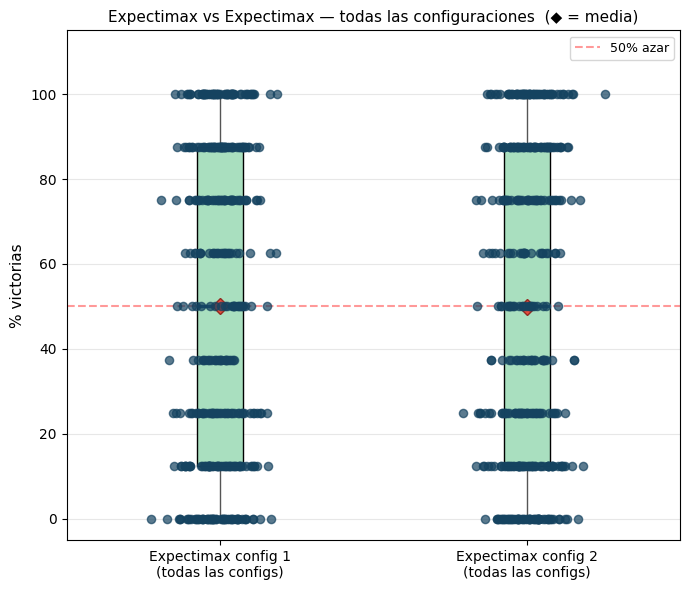


Agente                         │   Min │ Mediana │  Media │   Max
────────────────────────────────────────────────────────────
Expectimax config 1 (todas las configs) │    0% │     50% │  50.2% │  100%
Expectimax config 2 (todas las configs) │    0% │     50% │  49.8% │  100%


In [ ]:

datos  = [resultados_exp_vs_exp['exp1'], resultados_exp_vs_exp['exp2']]
labels = ['Expectimax config 1\n(todas las configs)', 'Expectimax config 2\n(todas las configs)']

fig, ax = plt.subplots(figsize=(7, 6))
bp = ax.boxplot(datos, labels=labels, patch_artist=True, showmeans=True,
                medianprops=dict(color='#1A5276', linewidth=2.5),
                meanprops=dict(marker='D', markerfacecolor='#E74C3C',
                               markeredgecolor='#922B21', markersize=8),
                whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
                flierprops=dict(marker='o', color='#555', alpha=0.4))

bp['boxes'][0].set_facecolor('#A9DFBF')
bp['boxes'][1].set_facecolor('#A9DFBF')

for i, rates in enumerate(datos):
    jitter = np.random.normal(i + 1, 0.07, size=len(rates))
    ax.scatter(jitter, rates, color='#154360', s=35, alpha=0.7, zorder=5)

ax.axhline(50, color='red', linestyle='--', alpha=0.4, label='50% azar')
ax.set_ylim(-5, 115)
ax.set_ylabel('% victorias', fontsize=11)
ax.set_title('Expectimax vs Expectimax — todas las configuraciones  (◆ = media)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


print(f"\n{'Agente':<30} │ {'Min':>5} │ {'Mediana':>7} │ {'Media':>6} │ {'Max':>5}")
print('─' * 60)
for label, rates in zip(labels, datos):
    arr = np.array(rates)
    print(f"{label.replace(chr(10),' '):<30} │ {arr.min():>4.0f}% │"
          f" {np.median(arr):>6.0f}% │ {arr.mean():>5.1f}% │ {arr.max():>4.0f}%")

In [ ]:
import json, re
from collections import defaultdict

NOTEBOOK_PATH = "isolation.ipynb"

with open(NOTEBOOK_PATH, encoding="utf-8") as f:
    nb = json.load(f)

raw_text = None
for cell in nb["cells"]:
    text = "".join("".join(o.get("text", [])) for o in cell.get("outputs", []))
    if re.search(r"\[\d+/392\] Exp\(d=", text):
        raw_text = text
        break

if raw_text is None:
    raise RuntimeError("No encontré el output de Expectimax vs Expectimax. "
                        "¿Guardaste el notebook (Ctrl+S) después de correr esa celda?")

parts = re.split(r"(\[\d+/392\] [^\n]*)\n", raw_text)
headers, contents = parts[1::2], parts[2::2]
pat = re.compile(r"\[(\d+)/392\] Exp\(d=(\d+),(\w+)\) vs Exp\(d=(\d+),(\w+)\)")

results_as_j1 = defaultdict(list)
results_as_j2 = defaultdict(list)

for h, c in zip(headers, contents):
    m = pat.match(h)
    if not m:
        continue
    _, d1, n1, d2, n2 = m.groups()
    wins = c.count("Player 1 WON")
    total = wins + c.count("Player 2 WON")
    wr = 100.0 * wins / total
    results_as_j1[(int(d1), n1)].append(wr)
    results_as_j2[(int(d2), n2)].append(100.0 - wr)

heurs = ['baseline','pure_mobility','mobility_heavy','aggressive',
         'space_control','balanced','pure_space']

print(f"{'Config':<25} {'d':>3} {'MedJ1':>8} {'MedJ2':>8} {'Promedio':>10}")
print('-'*60)

mejor, mejor_prom = None, -1
for d in [2, 3]:
    for h in heurs:
        key = (d, h)
        j1, j2 = results_as_j1.get(key), results_as_j2.get(key)
        if not j1 or not j2:
            continue
        med_j1, med_j2 = np.median(j1), np.median(j2)
        prom = (med_j1 + med_j2) / 2
        print(f'{h:<25} {d:>3} {med_j1:>7.2f}% {med_j2:>7.2f}% {prom:>9.2f}%')
        if prom > mejor_prom:
            mejor_prom, mejor = prom, (d, h)

print('-'*60)
print(f"\n✓ Mejor configuración Expectimax vs Expectimax: d={mejor[0]}, heurística={mejor[1]} ({mejor_prom:.1f}%)")

Config                      d    MedJ1    MedJ2   Promedio
------------------------------------------------------------
baseline                    2   75.00%   68.75%     71.88%
pure_mobility               2   87.50%   62.50%     75.00%
mobility_heavy              2   87.50%   75.00%     81.25%
aggressive                  2   87.50%   75.00%     81.25%
space_control               2   75.00%   68.75%     71.88%
balanced                    2   87.50%   75.00%     81.25%
pure_space                  2   75.00%   56.25%     65.62%
baseline                    3   37.50%   12.50%     25.00%
pure_mobility               3   37.50%   12.50%     25.00%
mobility_heavy              3   31.25%   12.50%     21.88%
aggressive                  3   25.00%   12.50%     18.75%
space_control               3   37.50%   12.50%     25.00%
balanced                    3   43.75%   12.50%     28.12%
pure_space                  3   43.75%   12.50%     28.12%
------------------------------------------------------

## AB vs AB 

In [50]:

resultados_ab_vs_ab = {'ab1': [], 'ab2': []}

configs_ab = [(d, n, fn) for d in [2, 3, 4] for n, fn in HEURISTICAS.items()]

total = len(configs_ab) * len(configs_ab) * 2
contador = 0

for d1, n1, fn1 in configs_ab:
    for d2, n2, fn2 in configs_ab:

        # AB1(J1) vs AB2(J2)
        contador += 1
        print(f"[{contador}/{total}] AB(d={d1},{n1}) vs AB(d={d2},{n2})")
        wr = run_config(
            agent1_fn=lambda fn=fn1, d=d1: MinimaxAgentAlphaBetaPruning(player=1, depth=d, eval_fn=fn),
            agent2_fn=lambda fn=fn2, d=d2: MinimaxAgentAlphaBetaPruning(player=2, depth=d, eval_fn=fn),
            verbose=False
        )
        resultados_ab_vs_ab['ab1'].append(wr)
        resultados_ab_vs_ab['ab2'].append(100.0 - wr)

        # AB2(J1) vs AB1(J2)
        contador += 1
        print(f"[{contador}/{total}] AB(d={d2},{n2}) vs AB(d={d1},{n1})")
        wr = run_config(
            agent1_fn=lambda fn=fn2, d=d2: MinimaxAgentAlphaBetaPruning(player=1, depth=d, eval_fn=fn),
            agent2_fn=lambda fn=fn1, d=d1: MinimaxAgentAlphaBetaPruning(player=2, depth=d, eval_fn=fn),
            verbose=False
        )
        resultados_ab_vs_ab['ab2'].append(wr)
        resultados_ab_vs_ab['ab1'].append(100.0 - wr)

print("\n Terminado")

[1/882] AB(d=2,baseline) vs AB(d=2,baseline)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 2 WON
[2/882] AB(d=2,baseline) vs AB(d=2,baseline)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
[3/882] AB(d=2,baseline) vs AB(d=2,pure_mobility)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 2 WON
[4/882] AB(d=2,pure_mobility) vs AB(d=2,baseline)
Player 1 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
[5/882] AB(d=2,baseline) vs AB(d=2,mobility_heavy)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
[6/882] AB(d=2,mobility_heavy) vs AB(d=2,baseline)
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
[7/882] AB(d=2,baseline) vs AB(d=2,aggressive)
Player 2 WON
Player 1 WON
Player 1 WO

### Boxplots AB vs AB

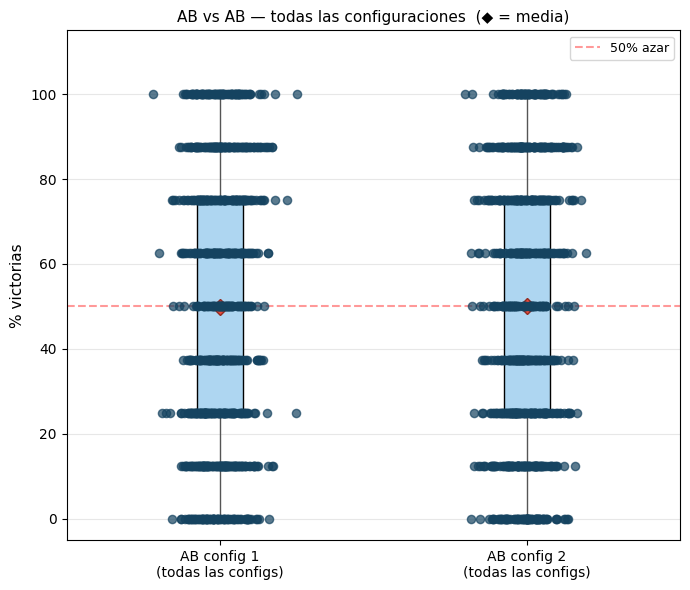


Agente                         │   Min │ Mediana │  Media │   Max
────────────────────────────────────────────────────────────
AB config 1 (todas las configs) │    0% │     50% │  49.9% │  100%
AB config 2 (todas las configs) │    0% │     50% │  50.1% │  100%


In [51]:

datos  = [resultados_ab_vs_ab['ab1'], resultados_ab_vs_ab['ab2']]
tick_labels = ['AB config 1\n(todas las configs)', 'AB config 2\n(todas las configs)']

fig, ax = plt.subplots(figsize=(7, 6))
bp = ax.boxplot(datos, tick_labels=tick_labels, patch_artist=True, showmeans=True,
                medianprops=dict(color='#1A5276', linewidth=2.5),
                meanprops=dict(marker='D', markerfacecolor='#E74C3C',
                               markeredgecolor='#922B21', markersize=8),
                whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
                flierprops=dict(marker='o', color='#555', alpha=0.4))

bp['boxes'][0].set_facecolor('#AED6F1')
bp['boxes'][1].set_facecolor('#AED6F1')

for i, rates in enumerate(datos):
    jitter = np.random.normal(i + 1, 0.07, size=len(rates))
    ax.scatter(jitter, rates, color='#154360', s=35, alpha=0.7, zorder=5)

ax.axhline(50, color='red', linestyle='--', alpha=0.4, label='50% azar')
ax.set_ylim(-5, 115)
ax.set_ylabel('% victorias', fontsize=11)
ax.set_title('AB vs AB — todas las configuraciones  (◆ = media)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Tabla resumen ---
print(f"\n{'Agente':<30} │ {'Min':>5} │ {'Mediana':>7} │ {'Media':>6} │ {'Max':>5}")
print('─' * 60)
for label, rates in zip(tick_labels, datos):
    arr = np.array(rates)
    print(f"{label.replace(chr(10),' '):<30} │ {arr.min():>4.0f}% │"
          f" {np.median(arr):>6.0f}% │ {arr.mean():>5.1f}% │ {arr.max():>4.0f}%")

## Random vs Random

In [ ]:

resultados_rand_vs_rand = {'rand1': [], 'rand2': []}

N_REPETICIONES = 10 

for i in range(N_REPETICIONES):
    print(f"[{i+1}/{N_REPETICIONES}] Random(J1) vs Random(J2)")
    wr = run_config(
        agent1_fn=lambda: RandomAgent(player=1),
        agent2_fn=lambda: RandomAgent(player=2),
        verbose=False
    )
    resultados_rand_vs_rand['rand1'].append(wr)
    resultados_rand_vs_rand['rand2'].append(100.0 - wr)

print("\n Terminado")

[1/10] Random(J1) vs Random(J2)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 2 WON
Player 2 WON
Player 1 WON
[2/10] Random(J1) vs Random(J2)
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
[3/10] Random(J1) vs Random(J2)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
[4/10] Random(J1) vs Random(J2)
Player 2 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 2 WON
Player 1 WON
[5/10] Random(J1) vs Random(J2)
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
[6/10] Random(J1) vs Random(J2)
Player 2 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
[7/10] Random(J1) vs Random(J2)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
[8/10] Random(J1) vs Random(J2)
Player 1 WON
Pla

### Boxplots Random vs Random

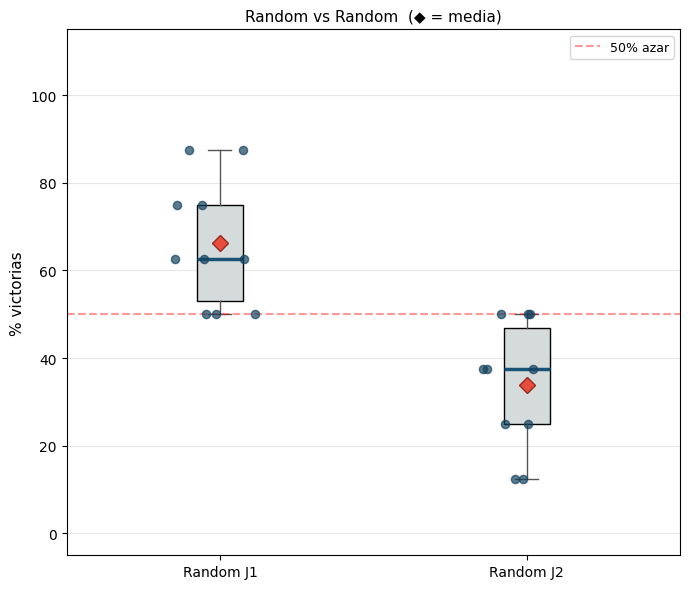


Agente          │   Min │ Mediana │  Media │   Max
──────────────────────────────────────────────────
Random J1       │   50% │     62% │  66.2% │   88%
Random J2       │   12% │     38% │  33.8% │   50%


In [ ]:

datos = [resultados_rand_vs_rand['rand1'], resultados_rand_vs_rand['rand2']]
tick_labels = ['Random J1', 'Random J2']

fig, ax = plt.subplots(figsize=(7, 6))
bp = ax.boxplot(datos, tick_labels=tick_labels, patch_artist=True, showmeans=True,
                medianprops=dict(color='#1A5276', linewidth=2.5),
                meanprops=dict(marker='D', markerfacecolor='#E74C3C',
                               markeredgecolor='#922B21', markersize=8),
                whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
                flierprops=dict(marker='o', color='#555', alpha=0.4))

bp['boxes'][0].set_facecolor('#D5DBDB')
bp['boxes'][1].set_facecolor('#D5DBDB')

for i, rates in enumerate(datos):
    jitter = np.random.normal(i + 1, 0.07, size=len(rates))
    ax.scatter(jitter, rates, color='#154360', s=35, alpha=0.7, zorder=5)

ax.axhline(50, color='red', linestyle='--', alpha=0.4, label='50% azar')
ax.set_ylim(-5, 115)
ax.set_ylabel('% victorias', fontsize=11)
ax.set_title('Random vs Random  (◆ = media)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'Agente':<15} │ {'Min':>5} │ {'Mediana':>7} │ {'Media':>6} │ {'Max':>5}")
print('─' * 50)
for label, rates in zip(tick_labels, datos):
    arr = np.array(rates)
    print(f"{label:<15} │ {arr.min():>4.0f}% │"
          f" {np.median(arr):>6.0f}% │ {arr.mean():>5.1f}% │ {arr.max():>4.0f}%")

## Stratagem vs Stratagem

In [54]:
resultados_strat_vs_strat = {'strat1': [], 'strat2': []}

N_REPETICIONES_STRAT = 10

for i in range(N_REPETICIONES_STRAT):
    print(f"[{i+1}/{N_REPETICIONES_STRAT}] Stratagem(J1) vs Stratagem(J2)")
    wr = run_config(
        agent1_fn=lambda: Stratagem(1),
        agent2_fn=lambda: Stratagem(2),
        verbose=False
    )
    resultados_strat_vs_strat['strat1'].append(wr)
    resultados_strat_vs_strat['strat2'].append(100.0 - wr)

print("\n Terminado")

[1/10] Stratagem(J1) vs Stratagem(J2)
Player 1 WON
Player 2 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 2 WON
[2/10] Stratagem(J1) vs Stratagem(J2)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
[3/10] Stratagem(J1) vs Stratagem(J2)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
[4/10] Stratagem(J1) vs Stratagem(J2)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
[5/10] Stratagem(J1) vs Stratagem(J2)
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
[6/10] Stratagem(J1) vs Stratagem(J2)
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
[7/10] Stratagem(J1) vs Stratagem(J2)
Player 1 WON
Player 1 WON
Player 1 WON
Player 1 WON
Player 2 WON
Player 1 WON
Player 1 WON
Player 1 WON
[8/10]

### Boxplots Strategem vs Strategem

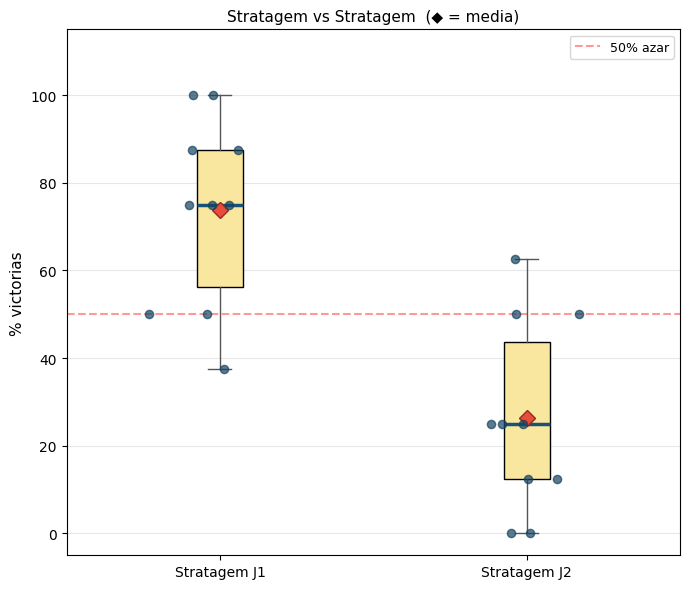


Agente          │   Min │ Mediana │  Media │   Max
──────────────────────────────────────────────────
Stratagem J1    │   38% │     75% │  73.8% │  100%
Stratagem J2    │    0% │     25% │  26.2% │   62%


In [ ]:
datos = [resultados_strat_vs_strat['strat1'], resultados_strat_vs_strat['strat2']]
tick_labels = ['Stratagem J1', 'Stratagem J2']

fig, ax = plt.subplots(figsize=(7, 6))
bp = ax.boxplot(datos, tick_labels=tick_labels, patch_artist=True, showmeans=True,
                medianprops=dict(color='#1A5276', linewidth=2.5),
                meanprops=dict(marker='D', markerfacecolor='#E74C3C',
                               markeredgecolor='#922B21', markersize=8),
                whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
                flierprops=dict(marker='o', color='#555', alpha=0.4))

bp['boxes'][0].set_facecolor('#F9E79F')
bp['boxes'][1].set_facecolor('#F9E79F')

for i, rates in enumerate(datos):
    jitter = np.random.normal(i + 1, 0.07, size=len(rates))
    ax.scatter(jitter, rates, color='#154360', s=35, alpha=0.7, zorder=5)

ax.axhline(50, color='red', linestyle='--', alpha=0.4, label='50% azar')
ax.set_ylim(-5, 115)
ax.set_ylabel('% victorias', fontsize=11)
ax.set_title('Stratagem vs Stratagem  (◆ = media)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


print(f"\n{'Agente':<15} │ {'Min':>5} │ {'Mediana':>7} │ {'Media':>6} │ {'Max':>5}")
print('─' * 50)
for label, rates in zip(tick_labels, datos):
    arr = np.array(rates)
    print(f"{label:<15} │ {arr.min():>4.0f}% │"
          f" {np.median(arr):>6.0f}% │ {arr.mean():>5.1f}% │ {arr.max():>4.0f}%")